In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')

data_folder = Path("../data")
dataset_location = data_folder / "creditcard.csv"

# Necessary for notebook to see src
import sys
sys.path.append('..')

from src import tsne_visualization, pca_visualization, DateTimeFeatureExtractor

Device: cuda


In [12]:
original_dataset = pd.read_csv(dataset_location)
dataset = original_dataset.copy(deep=True)

In [13]:
# No Null values

dataset.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [14]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# Imbalance

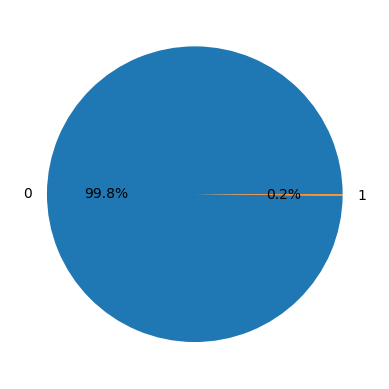

In [15]:
class_value_counts = dataset.Class.value_counts()
plt.pie(class_value_counts, labels=class_value_counts.index,  autopct='%1.1f%%')
plt.show()

# Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(dataset, test_size=0.2, random_state=42, shuffle=True)

# CTGAN

In [17]:
from ctgan import CTGAN

ctgan = CTGAN(epochs=10, verbose=True)

ctgan.fit(train_set, discrete_columns=['Class'])

Gen. (-4.21) | Discrim. (0.02): 100%|██████████| 10/10 [01:36<00:00,  9.65s/it]


# Sampling

In [18]:
n_samples = len(train_set)

samples_list = []
sample_count = 0

iteration = 0

while True:
    synthteic_data_ones = ctgan.sample(n_samples, condition_column='Class', condition_value=1)
    samples_one = synthteic_data_ones[synthteic_data_ones['Class'] == 1].copy(deep=True)
    
    if sample_count + len(samples_one) > n_samples:
        break
    
    samples_list.append(samples_one)
    sample_count += len(samples_one)
    
    iteration += 1
    print(f'Iteration: {iteration:>5} Sample Count: {sample_count:>10}')
    
    del synthteic_data_ones

Iteration:     1 Sample Count:      32556
Iteration:     2 Sample Count:      65190
Iteration:     3 Sample Count:      97758
Iteration:     4 Sample Count:     130320
Iteration:     5 Sample Count:     163067
Iteration:     6 Sample Count:     195492


# Augmentation

In [21]:
synthetic_data = pd.concat(samples_list, axis=0)
augmented_data = pd.concat([train_set, synthetic_data], axis=0)

In [22]:
augmented_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
223361,143352.000000,1.955041,-0.380783,-0.315013,0.330155,-0.509374,-0.086197,-0.627978,0.035994,1.054560,...,0.238197,0.968305,0.053208,-0.278602,-0.044999,-0.216780,0.045168,-0.047145,9.990000,0
165061,117173.000000,-0.400975,-0.626943,1.555339,-2.017772,-0.107769,0.168310,0.017959,-0.401619,0.040378,...,-0.153485,0.421703,0.113442,-1.004095,-1.176695,0.361924,-0.370469,-0.144792,45.900000,0
238186,149565.000000,0.072509,0.820566,-0.561351,-0.709897,1.080399,-0.359429,0.787858,0.117276,-0.131275,...,-0.314638,-0.872959,0.083391,0.148178,-0.431459,0.119690,0.206395,0.070288,11.990000,0
150562,93670.000000,-0.535045,1.014587,1.750679,2.769390,0.500089,1.002270,0.847902,-0.081323,0.371579,...,0.063525,0.443431,-0.072754,0.448192,-0.655203,-0.181038,-0.093013,-0.064931,117.440000,0
138452,82655.000000,-4.026938,1.897371,-0.429786,-0.029571,-0.855751,-0.480406,-0.435632,1.313760,0.536044,...,-0.480691,-0.230369,0.250717,0.066399,0.470787,0.245335,0.286904,-0.322672,25.760000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227791,36996.749631,-15.672335,11.078725,-0.300694,11.410814,-5.435397,-1.210232,-14.736892,-0.845647,-5.765267,...,-0.161098,0.064788,0.235412,0.747911,0.073776,0.686743,0.371654,-1.512640,13.411434,1
227803,120201.111364,0.552726,0.595324,-3.053691,1.289506,3.706844,0.430494,-0.484177,0.766875,-0.535448,...,-0.415193,-0.590089,0.118938,0.079662,0.501085,0.694499,0.138425,0.161380,34.844260,1
227805,28122.015896,-9.122422,10.347063,-1.295734,9.222375,-1.440491,0.428281,-11.824340,0.788624,-3.089245,...,2.931168,-1.646024,-1.003993,-0.182412,0.376444,-0.270553,1.355512,-0.886400,11.085945,1
227808,77959.772801,-0.529569,-1.406595,2.576988,0.656639,0.733390,-0.604933,-1.102221,-0.012630,0.064093,...,-2.386304,-0.654628,0.228469,-0.115764,-0.558005,0.806966,-0.216149,0.173573,5.818766,1


# Prediction

In [32]:
from sklearn.preprocessing import RobustScaler

X_train, y_train = train_set.iloc[:, :-1], train_set.iloc[:, -1] 
X_train_augmented, y_train_augmented = augmented_data.iloc[:, :-1], augmented_data.iloc[:, -1] 

train_scaler = RobustScaler()
augmented_scaler = RobustScaler()

X_train = train_scaler.fit_transform(X_train)
X_train_augmented = augmented_scaler.fit_transform(X_train_augmented)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

normal_model = LogisticRegression()
augmented_model = LogisticRegression()

normal_model.fit(X_train, y_train)
augmented_model.fit(X_train_augmented, y_train_augmented)

LogisticRegression()

# Normal Prediction

In [34]:
X_test, y_test = test_set.iloc[:, :-1], test_set.iloc[:, -1] 

test_scaled = train_scaler.transform(X_test)

print(classification_report(y_test, normal_model.predict(test_scaled)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.57      0.69        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



# Augmented Prediction

In [35]:
test_scaled = augmented_scaler.transform(X_test)

print(classification_report(y_test, augmented_model.predict(test_scaled)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.85      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.92      0.78     56962
weighted avg       1.00      1.00      1.00     56962

